In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%pip install librosa

# audio
import librosa
import librosa.display

# classical ML
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
)
from sklearn.preprocessing import LabelEncoder, label_binarize

%pip install xgboost

from xgboost import XGBClassifier

%pip install catboost

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None
    print("Install CatBoost for full results: pip install catboost")

# deep learning (Keras 3 / TF)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D,
    Concatenate,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization,
    Activation,
)
from tensorflow.keras.preprocessing.sequence import pad_sequences

warnings.filterwarnings("ignore", category=UserWarning)


## Importing the dataset from Kaggle  ##
This dataset contains 2500 wav files, 500 each for 5 different moods.The dataset is from kaggle.

In [2]:
#!pip install kaggle catboost


In [3]:
#!kaggle datasets download -d auliayasmin/music-mood-classification


In [4]:
#!unzip music-mood-classification.zip


## Notebook structure

1. **Setup** — imports and configuration (single place).
2. **Data** — tabular features and mel spectrograms are each built **once**; all models reuse these arrays (no duplicated loading loops).
3. **Classical models** — `RandomizedSearchCV` hyperparameter search, then evaluation across several **train/test data seeds** and **model random seeds** (mean ± std). Includes Random Forest, XGBoost (multiclass), **CatBoost**, **one-vs-rest XGBoost** (five binary models), **ROC** (one-vs-rest), and **5×5 confusion matrices**.
4. **Deep learning** — **U-Net–style** 2D model on padded mel maps; two training seeds for a variability summary.

Audio is handled with **librosa**.

### Tabular features (MFCC / chroma / contrast / ZCR)

These vectors feed tree ensembles (Random Forest, XGBoost, CatBoost). The same `X_tabular` and `y_tabular` are reused in every classical-model cell below.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# --- shared configuration (paths, sampling, reproducibility) ---
# DATASET_PATH = "dataset"
DATASET_PATH = "/content/drive/MyDrive/thesis/dataset"

MOODS = ["aggressive", "dramatic", "happy", "romantic", "sad"]
SAMPLES_PER_CLASS = 500  # increase if you have compute budget (full folder has 500 each)
N_MELS = 128

# Multiple train/test splits and model initialisations (report mean ± std)
DATA_SEEDS = (0, 17, 42, 99, 123) #(0, 17, 42, 99, 123)
MODEL_SEEDS = (7, 42, 99) #(7, 42, 99)
TUNING_RANDOM_STATE = 42
TUNING_CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=TUNING_RANDOM_STATE)

features_tabular = []
labels = []


In [13]:
def extract_features(file_path):
    """MFCC, chroma, spectral contrast, and ZCR summaries for tree-based models."""
    try:
        y, sr = librosa.load(file_path, sr=None)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfcc.T, axis=0)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma.T, axis=0)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        contrast_mean = np.mean(contrast.T, axis=0)
        zcr = librosa.feature.zero_crossing_rate(y)
        zcr_mean = np.mean(zcr)
        return np.hstack((mfcc_mean, chroma_mean, contrast_mean, zcr_mean))
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


In [14]:
# Build tabular dataset once for all classical models
for mood in MOODS:
    mood_folder = os.path.join(DATASET_PATH, mood)
    files = sorted(os.listdir(mood_folder))[:SAMPLES_PER_CLASS]
    for file_name in files:
        fp = os.path.join(mood_folder, file_name)
        vec = extract_features(fp)
        if vec is not None:
            features_tabular.append(vec)
            labels.append(mood)

X_tabular = np.asarray(features_tabular, dtype=np.float32)
y_labels = np.asarray(labels)
print("Tabular shape:", X_tabular.shape, "labels:", y_labels.shape)


Tabular shape: (2500, 33) labels: (2500,)


In [15]:
print("First rows (features):", X_tabular[:2])
print("First labels:", y_labels[:5])


First rows (features): [[-1.31995956e+02  2.06185318e+02 -4.75330086e+01 -1.09593649e+01
   1.13534660e+01  1.54600401e+01  8.31403911e-01  1.38233986e+01
   3.89158535e+00  6.02401638e+00  2.21398687e+00  8.09124470e+00
   4.81216478e+00  6.98612094e-01  6.07390642e-01  5.79352140e-01
   6.17072940e-01  6.25317156e-01  7.29506969e-01  6.38447106e-01
   5.45594811e-01  5.89931190e-01  5.66412807e-01  5.37877202e-01
   5.48018754e-01  1.18697462e+01  6.95737839e+00  1.24280558e+01
   1.24634237e+01  1.50916815e+01  2.12540627e+01  3.67181168e+01
   4.06383686e-02]
 [-1.60421234e+02  2.26486557e+02 -4.29674530e+01 -1.62894993e+01
   1.80271130e+01  9.20457935e+00  4.87327099e+00  1.22551680e+01
   4.40152359e+00  3.63648415e+00  3.75024056e+00  6.74352217e+00
   5.85993576e+00  7.04383016e-01  5.98969519e-01  5.93531013e-01
   6.51379108e-01  6.36168838e-01  7.20185935e-01  6.16505861e-01
   5.47048032e-01  5.85603416e-01  5.61079502e-01  5.35898387e-01
   5.61423719e-01  1.12722435e+01 

In [16]:
label_encoder = LabelEncoder()
y_tabular = label_encoder.fit_transform(y_labels)
class_names = label_encoder.classes_
n_classes = len(class_names)
print("Classes (label order):", list(class_names))


Classes (label order): [np.str_('aggressive'), np.str_('dramatic'), np.str_('happy'), np.str_('romantic'), np.str_('sad')]


### Mel spectrograms (shared tensor pipeline for deep learning)


In [17]:
def extract_mel_spectrogram(file_path, n_mels=N_MELS):
    """Mel spectrogram as (time, n_mels) in dB scale."""
    try:
        y, sr = librosa.load(file_path, sr=None)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        return mel_db.T
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


mel_specs = []
mel_label_indices = []
for mood in MOODS:
    mood_folder = os.path.join(DATASET_PATH, mood)
    files = sorted(os.listdir(mood_folder))[:SAMPLES_PER_CLASS]
    k = MOODS.index(mood)
    n_ok = 0
    for file_name in files:
        fp = os.path.join(mood_folder, file_name)
        spec = extract_mel_spectrogram(fp)
        if spec is not None:
            mel_specs.append(spec)
            mel_label_indices.append(k)
            n_ok += 1
    print(f"Mel spectrograms loaded for {mood}: {n_ok} files")

y_mel = np.asarray(mel_label_indices, dtype=np.int32)
print("Total mel samples:", len(mel_specs), "labels:", y_mel.shape)


Mel spectrograms loaded for aggressive: 500 files
Mel spectrograms loaded for dramatic: 500 files
Mel spectrograms loaded for happy: 500 files
Mel spectrograms loaded for romantic: 500 files
Mel spectrograms loaded for sad: 500 files
Total mel samples: 2500 labels: (2500,)


### Visual inspection of mel spectrograms


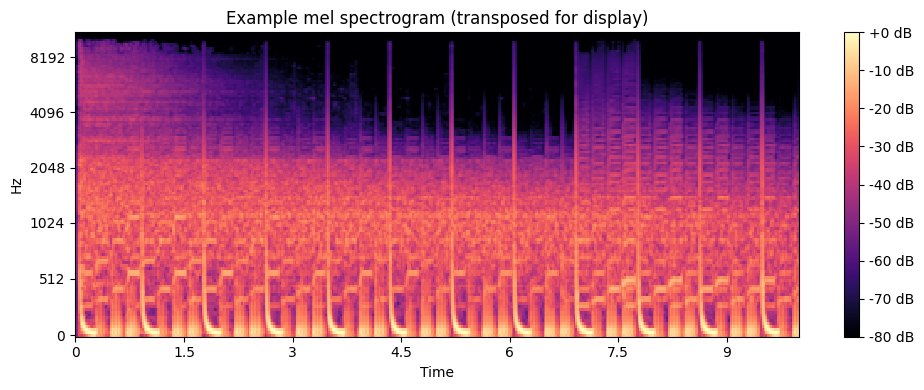

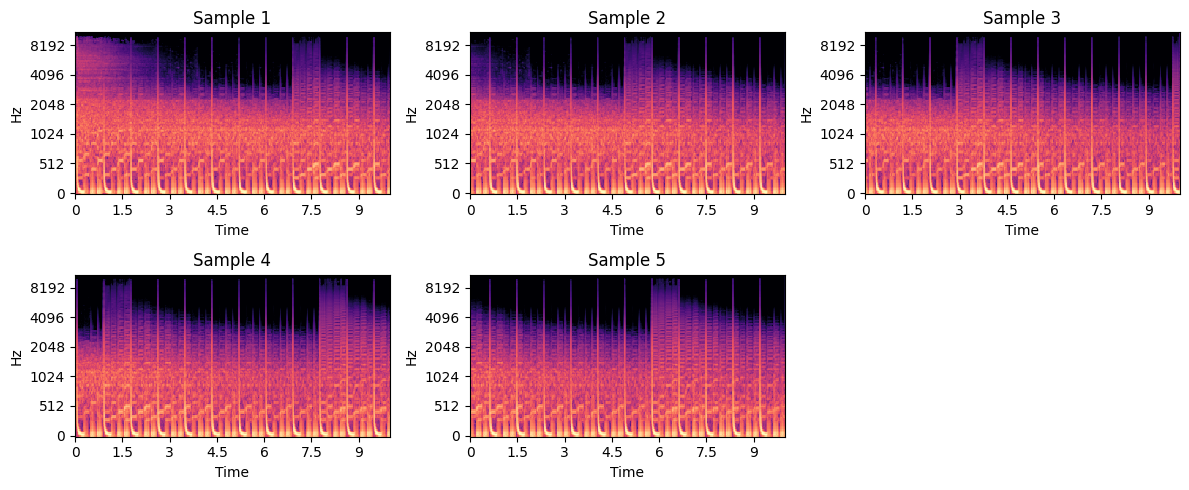

In [18]:
# Quick visual check (same files as tabular pipeline)
example = mel_specs[0]
plt.figure(figsize=(10, 4))
librosa.display.specshow(example.T, x_axis="time", y_axis="mel", sr=22050, hop_length=512)
plt.colorbar(format="%+2.0f dB")
plt.title("Example mel spectrogram (transposed for display)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for i in range(min(5, len(mel_specs))):
    plt.subplot(2, 3, i + 1)
    librosa.display.specshow(mel_specs[i].T, x_axis="time", y_axis="mel", sr=22050, hop_length=512)
    plt.title(f"Sample {i + 1}")
plt.tight_layout()
plt.show()


## Classical models (Random Forest, XGBoost, CatBoost)

Tabular features are built **once** above. Here we (i) tune hyperparameters with **RandomizedSearchCV** on stratified CV, (ii) re-fit on several **train/test splits** (`DATA_SEEDS`) and **model random seeds** (`MODEL_SEEDS`), and report **mean ± standard deviation** of test accuracy. **ROC** (one-vs-rest) and **5×5 confusion matrices** use a single reference hold-out (`reference_data_seed=42`) with the tuned hyperparameters for readability.


In [19]:
# ----- 1) Hyperparameter search (one pass on full data, CV only — no fixed test set) -----

def summarize_multiseed(clf_factory, name):
    """clf_factory(ms) -> unfitted sklearn-compatible estimator with random_state set."""
    scores = []
    for ds in DATA_SEEDS:
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_tabular,
            y_tabular,
            test_size=0.2,
            stratify=y_tabular,
            random_state=ds,
        )
        for ms in MODEL_SEEDS:
            clf = clf_factory(ms)
            clf.fit(X_tr, y_tr)
            scores.append(accuracy_score(y_te, clf.predict(X_te)))
    scores = np.asarray(scores, dtype=np.float64)
    print(
        f"{name}: mean acc = {scores.mean():.4f}, std = {scores.std(ddof=1):.4f} "
        f"(over {len(scores)} runs: |DATA_SEEDS|×|MODEL_SEEDS|)"
    )
    return scores


# Random Forest
rf_param_dist = {
    "n_estimators": [100, 200, 350],
    "max_depth": [None, 12, 20, 28],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=TUNING_RANDOM_STATE),
    rf_param_dist,
    n_iter=18,
    cv=TUNING_CV,
    random_state=TUNING_RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)
rf_search.fit(X_tabular, y_tabular)
print("Best RF params:", rf_search.best_params_)

rf_scores = summarize_multiseed(
    lambda ms: RandomForestClassifier(**rf_search.best_params_, random_state=ms),
    "RandomForest (tuned)",
)

# XGBoost (multiclass)
xgb_param_dist = {
    "n_estimators": [150, 300, 500],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.02, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "min_child_weight": [1, 3, 5],
}
xgb_base = XGBClassifier(
    objective="multi:softprob",
    num_class=int(n_classes),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=TUNING_RANDOM_STATE,
)
xgb_search = RandomizedSearchCV(
    xgb_base,
    xgb_param_dist,
    n_iter=18,
    cv=TUNING_CV,
    random_state=TUNING_RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)
xgb_search.fit(X_tabular, y_tabular)
print("Best XGB (multiclass) params:", xgb_search.best_params_)

xgb_scores = summarize_multiseed(
    lambda ms: XGBClassifier(
        **xgb_search.best_params_,
        objective="multi:softprob",
        num_class=int(n_classes),
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=ms,
    ),
    "XGBoost multiclass (tuned)",
)

# CatBoost — strong default for tabular / ordered targets; here labels are still numeric classes
if CatBoostClassifier is None:
    cb_search = None
    print("Skipping CatBoost (package not installed).")
else:
    cb_param_dist = {
        "depth": [4, 6, 8, 10],
        "learning_rate": [0.03, 0.07, 0.12],
        "l2_leaf_reg": [1, 3, 5, 9],
        "iterations": [250, 400, 600],
    }
    cb_base = CatBoostClassifier(
        loss_function="MultiClass",
        classes_count=int(n_classes),
        verbose=False,
        random_seed=TUNING_RANDOM_STATE,
        allow_writing_files=False,
    )
    cb_search = RandomizedSearchCV(
        cb_base,
        cb_param_dist,
        n_iter=14,
        cv=TUNING_CV,
        random_state=TUNING_RANDOM_STATE,
        n_jobs=1,
        verbose=0,
    )
    cb_search.fit(X_tabular, y_tabular)
    print("Best CatBoost params:", cb_search.best_params_)

    def cat_factory(ms):
        return CatBoostClassifier(
            **cb_search.best_params_,
            loss_function="MultiClass",
            classes_count=int(n_classes),
            verbose=False,
            random_seed=int(ms),
            allow_writing_files=False,
        )

    cb_scores = summarize_multiseed(cat_factory, "CatBoost (tuned)")

# Reference split for plots / reports
REF_SEED = 42
X_ref_tr, X_ref_te, y_ref_tr, y_ref_te = train_test_split(
    X_tabular,
    y_tabular,
    test_size=0.2,
    stratify=y_tabular,
    random_state=REF_SEED,
)

rf_ref = RandomForestClassifier(**rf_search.best_params_, random_state=REF_SEED)
rf_ref.fit(X_ref_tr, y_ref_tr)

xgb_ref = XGBClassifier(
    **xgb_search.best_params_,
    objective="multi:softprob",
    num_class=int(n_classes),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=REF_SEED,
)
xgb_ref.fit(X_ref_tr, y_ref_tr)

if CatBoostClassifier is not None:
    cb_ref = CatBoostClassifier(
        **cb_search.best_params_,
        loss_function="MultiClass",
        classes_count=int(n_classes),
        verbose=False,
        random_seed=REF_SEED,
        allow_writing_files=False,
    )
    cb_ref.fit(X_ref_tr, y_ref_tr)

print("\nReference split (seed=42) — classification report (Random Forest):")
print(classification_report(y_ref_te, rf_ref.predict(X_ref_te), target_names=class_names))


Best RF params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 28}
RandomForest (tuned): mean acc = 0.9521, std = 0.0062 (over 15 runs: |DATA_SEEDS|×|MODEL_SEEDS|)
Best XGB (multiclass) params: {'subsample': 0.85, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.1, 'colsample_bytree': 0.85}
XGBoost multiclass (tuned): mean acc = 0.9521, std = 0.0056 (over 15 runs: |DATA_SEEDS|×|MODEL_SEEDS|)
Best CatBoost params: {'learning_rate': 0.03, 'l2_leaf_reg': 1, 'iterations': 600, 'depth': 10}
CatBoost (tuned): mean acc = 0.9556, std = 0.0045 (over 15 runs: |DATA_SEEDS|×|MODEL_SEEDS|)

Reference split (seed=42) — classification report (Random Forest):
              precision    recall  f1-score   support

  aggressive       0.99      0.97      0.98       100
    dramatic       0.97      0.98      0.98       100
       happy       0.97      0.99      0.98       100
    romantic       0.90      0.94      0.9

In [20]:
# ----- One-vs-rest: five separate XGBoost models (binary), ensemble by argmax of P(class) -----

def build_binary_xgb(ms):
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=int(xgb_search.best_params_["n_estimators"]),
        max_depth=int(xgb_search.best_params_["max_depth"]),
        learning_rate=float(xgb_search.best_params_["learning_rate"]),
        subsample=float(xgb_search.best_params_["subsample"]),
        colsample_bytree=float(xgb_search.best_params_["colsample_bytree"]),
        min_child_weight=int(xgb_search.best_params_["min_child_weight"]),
        tree_method="hist",
        random_state=int(ms),
    )


ovr_scores = []
for ds in DATA_SEEDS:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_tabular,
        y_tabular,
        test_size=0.2,
        stratify=y_tabular,
        random_state=ds,
    )
    for ms in MODEL_SEEDS:
        prob_cols = []
        for k in range(n_classes):
            y_bin = (y_tr == k).astype(np.int32)
            m = build_binary_xgb(ms)
            m.fit(X_tr, y_bin)
            prob_cols.append(m.predict_proba(X_te)[:, 1])
        P = np.column_stack(prob_cols)
        pred = np.argmax(P, axis=1)
        ovr_scores.append(accuracy_score(y_te, pred))

ovr_scores = np.asarray(ovr_scores, dtype=np.float64)
print(
    "XGBoost OvR (5 binary models, argmax): "
    f"mean acc = {ovr_scores.mean():.4f}, std = {ovr_scores.std(ddof=1):.4f}"
)

# Fit OvR on reference split for ROC / confusion alongside multiclass models
ovr_prob_cols = []
for k in range(n_classes):
    y_bin = (y_ref_tr == k).astype(np.int32)
    mk = build_binary_xgb(REF_SEED)
    mk.fit(X_ref_tr, y_bin)
    ovr_prob_cols.append(mk.predict_proba(X_ref_te)[:, 1])
P_ovr = np.column_stack(ovr_prob_cols)
# renormalise rows so they sum to 1 (optional, helps interpretation)
P_ovr = P_ovr / P_ovr.sum(axis=1, keepdims=True)
y_ovr_pred = np.argmax(P_ovr, axis=1)
print("OvR reference accuracy:", accuracy_score(y_ref_te, y_ovr_pred))


XGBoost OvR (5 binary models, argmax): mean acc = 0.9529, std = 0.0049
OvR reference accuracy: 0.958


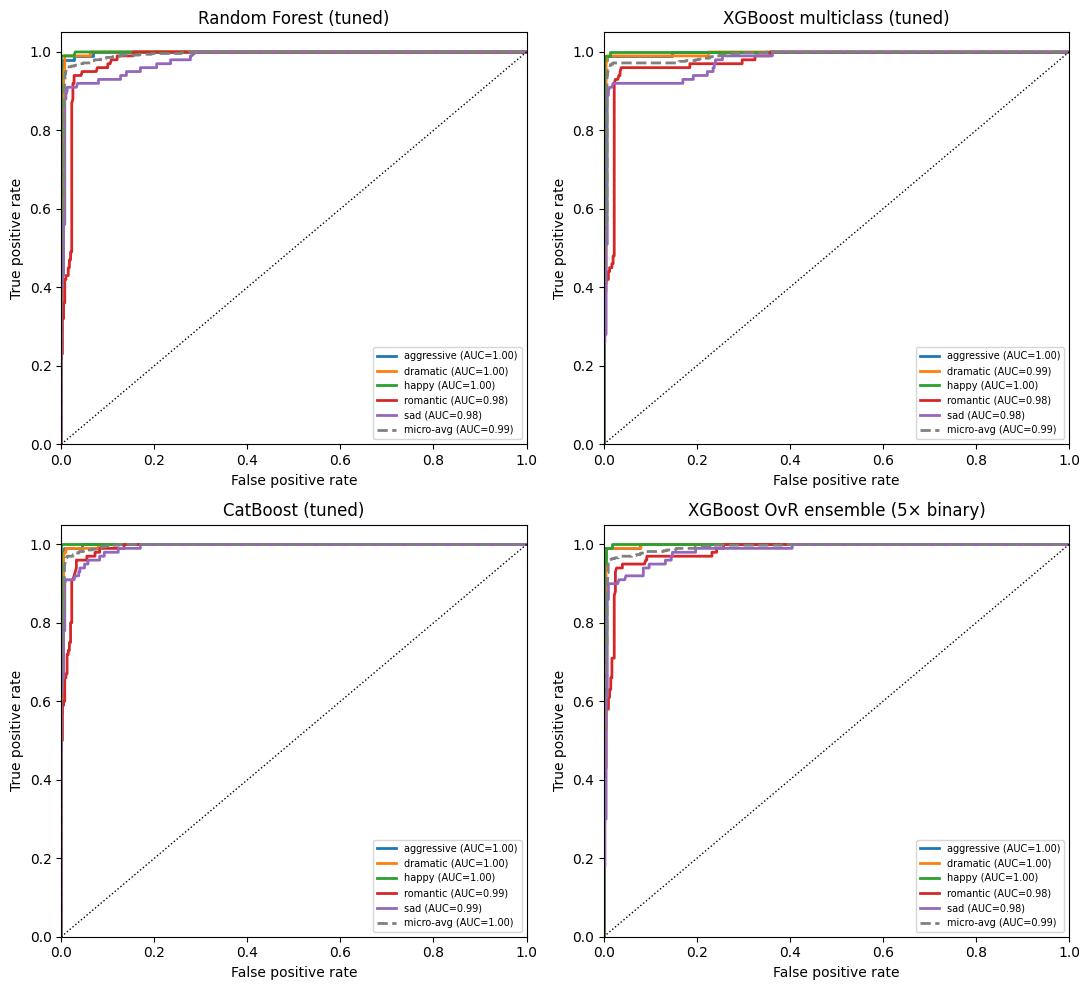

In [21]:
# ----- Multiclass ROC (one-vs-rest) on the reference test set -----

y_test_bin = label_binarize(y_ref_te, classes=np.arange(n_classes))


def plot_multiclass_roc(y_score, title, ax):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    for i, cname in enumerate(class_names):
        ax.plot(fpr[i], tpr[i], lw=2, label=f"{cname} (AUC={roc_auc[i]:.2f})")
    ax.plot(fpr["micro"], tpr["micro"], linestyle="--", color="gray", lw=2, label=f"micro-avg (AUC={roc_auc['micro']:.2f})")
    ax.plot([0, 1], [0, 1], "k:", lw=1)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.05)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(title)
    ax.legend(fontsize=7, loc="lower right")


fig, axes = plt.subplots(2, 2, figsize=(11, 10))
plot_multiclass_roc(rf_ref.predict_proba(X_ref_te), "Random Forest (tuned)", axes[0, 0])
plot_multiclass_roc(xgb_ref.predict_proba(X_ref_te), "XGBoost multiclass (tuned)", axes[0, 1])
if CatBoostClassifier is not None:
    plot_multiclass_roc(cb_ref.predict_proba(X_ref_te), "CatBoost (tuned)", axes[1, 0])
else:
    axes[1, 0].set_visible(False)
plot_multiclass_roc(P_ovr, "XGBoost OvR ensemble (5× binary)", axes[1, 1])
plt.tight_layout()
plt.show()


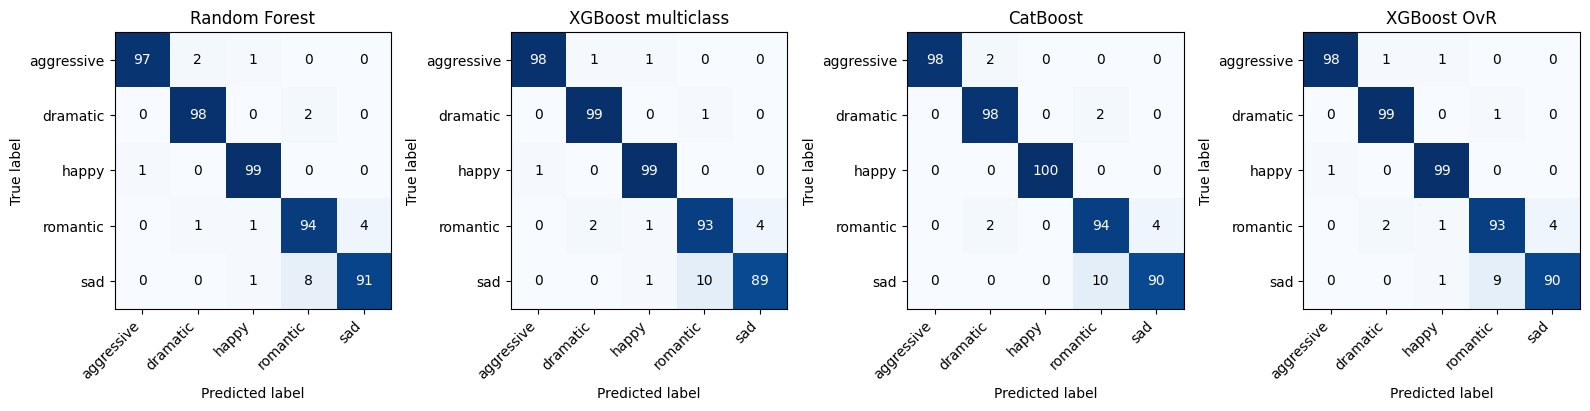

In [22]:
# ----- 5 × 5 confusion matrices on the reference split -----


def plot_confusion(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))
    ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax.set_title(title)
    tick_marks = np.arange(len(class_names))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")
    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"), ha="center", va="center", color="white" if cm[i, j] > thresh else "black")


fig, axes = plt.subplots(1, 3 if CatBoostClassifier is None else 4, figsize=(4 * (3 if CatBoostClassifier is None else 4), 4))
axes = np.atleast_1d(axes)
idx = 0
plot_confusion(y_ref_te, rf_ref.predict(X_ref_te), "Random Forest", axes[idx])
idx += 1
plot_confusion(y_ref_te, xgb_ref.predict(X_ref_te), "XGBoost multiclass", axes[idx])
idx += 1
if CatBoostClassifier is not None:
    plot_confusion(y_ref_te, cb_ref.predict(X_ref_te), "CatBoost", axes[idx])
    idx += 1
plot_confusion(y_ref_te, y_ovr_pred, "XGBoost OvR", axes[idx])
plt.tight_layout()
plt.show()


## Deep learning: U-Net–style encoder–decoder on mel spectrograms

Each clip is padded to a common time length and viewed as a **2D map** (time × mel bins). A compact **U-Net** (contracting path, bottleneck, expanding path with **skip connections**) uses **(2,1) pooling** so the mel dimension is preserved for stable skip concatenation; only the time axis is downsampled. A global pool and softmax head perform **5-way mood classification**. **R2U-Net** (recurrent residual U-Net) would replace each conv block with recurrent residual blocks in the same skeleton; it is a natural next step if you need more capacity.


In [23]:
# Train / test for deep learning only (separate variables from tabular pipeline)
DL_SEEDS = (42, 2025)
dl_histories = []
dl_eval_scores = []

for dl_seed in DL_SEEDS:
    X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
        mel_specs,
        y_mel,
        test_size=0.2,
        stratify=y_mel,
        random_state=dl_seed,
    )
    max_time = int(max(s.shape[0] for s in X_tr_m))
    max_time = int(np.ceil(max_time / 4) * 4)  # align time axis for two (2,1) poolings

    def pad_list(lst):
        return pad_sequences(lst, maxlen=max_time, padding="post", dtype="float32", truncating="post")

    Xtr = pad_list(X_tr_m)[..., np.newaxis]
    Xte = pad_list(X_te_m)[..., np.newaxis]
    input_shape = (max_time, N_MELS, 1)

    def conv_block(x, filters):
        x = Conv2D(filters, (3, 3), padding="same")(x)
        x = BatchNormalization()(x)
        x = Activation("relu")(x)
        x = Conv2D(filters, (3, 3), padding="same")(x)
        x = BatchNormalization()(x)
        x = Activation("relu")(x)
        return x

    def build_unet_classifier(input_shape, num_classes, base=32):
        inp = Input(shape=input_shape)
        c1 = conv_block(inp, base)
        p1 = MaxPooling2D((2, 1))(c1)
        c2 = conv_block(p1, base * 2)
        p2 = MaxPooling2D((2, 1))(c2)
        c3 = conv_block(p2, base * 4)
        u2 = UpSampling2D((2, 1))(c3)
        u2 = Concatenate()([u2, c2])
        c_up2 = conv_block(u2, base * 2)
        u1 = UpSampling2D((2, 1))(c_up2)
        u1 = Concatenate()([u1, c1])
        c_up1 = conv_block(u1, base)
        gap = GlobalAveragePooling2D()(c_up1)
        gap = Dropout(0.25)(gap)
        out = Dense(num_classes, activation="softmax")(gap)
        return Model(inp, out)

    tf.keras.utils.set_random_seed(dl_seed)
    unet_clf = build_unet_classifier(input_shape, n_classes, base=32)
    unet_clf.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    hist = unet_clf.fit(
        Xtr,
        y_tr_m,
        validation_data=(Xte, y_te_m),
        epochs=25,
        batch_size=16,
        verbose=1,
    )
    loss, acc = unet_clf.evaluate(Xte, y_te_m, verbose=0)
    dl_histories.append(hist)
    dl_eval_scores.append(acc)
    print(f"DL seed {dl_seed}: test accuracy = {acc:.4f}")

dl_eval_scores = np.asarray(dl_eval_scores, dtype=np.float64)
print(
    f"U-Net–style classifier: mean test acc over DL_SEEDS = {dl_eval_scores.mean():.4f}, "
    f"std = {dl_eval_scores.std(ddof=1) if len(dl_eval_scores) > 1 else 0.0:.4f}"
)


Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 101s 439ms/step - accuracy: 0.4730 - loss: 1.2529 - val_accuracy: 0.2280 - val_loss: 3.1055
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 364ms/step - accuracy: 0.5770 - loss: 1.0860 - val_accuracy: 0.5480 - val_loss: 1.1403
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 365ms/step - accuracy: 0.6045 - loss: 1.0013 - val_accuracy: 0.5040 - val_loss: 1.4868
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 368ms/step - accuracy: 0.6310 - loss: 0.9413 - val_accuracy: 0.4740 - val_loss: 1.5265
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 368ms/step - accuracy: 0.6430 - loss: 0.8999 - val_accuracy: 0.4260 - val_loss: 1.8442
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 366ms/step - accuracy: 0.6790 - loss: 0.8495 - val_accuracy: 0.3540 - val_loss: 3.4070
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 369ms/step - accuracy: 0.6965 - loss: 0.8060 - val_accuracy: 0.6320 - val_loss: 0.9534
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 368ms/step - accuracy: 0.7105 - loss: 